In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pylab as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder,LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error,r2_score

In [3]:
df = pd.read_csv(r'C:\Users\Miras\Desktop\machine learning\mini proect\data\used-bikes.csv')
df

,bike_name,price,city,kms_driven,owner,age,power,brand,Original Price
0,TVS Star City Plus Dual Tone 110cc,35000,Ahmedabad,17654,First Owner,3,110,TVS,82500
1,Royal Enfield Classic 350cc,119900,Delhi,11000,First Owner,4,350,Royal Enfield,230000
2,Triumph Daytona 675R,600000,Delhi,110,First Owner,8,675,Triumph,1100000
3,TVS Apache RTR 180cc,65000,Bangalore,16329,First Owner,4,180,TVS,140000
4,Yamaha FZ S V 2.0 150cc-Ltd. Edition,80000,Bangalore,10000,First Owner,3,150,Yamaha,150000
...,...,...,...,...,...,...,...,...,...
7307,Hero Hunk Rear Disc 150cc,25000,Delhi,48587,First Owner,8,150,Hero,120000
7308,Bajaj Avenger 220cc,35000,Bangalore,60000,First Owner,9,220,Bajaj,160000
7309,Harley-Davidson Street 750 ABS,450000,Jodhpur,3430,First Owner,4,750,Harley-Davidson,630000
7310,Bajaj Dominar 400 ABS,139000,Hyderabad,21300,First Owner,4,400,Bajaj,245000


In [4]:
print(df.head())

                              bike_name   price       city  kms_driven  \
0    TVS Star City Plus Dual Tone 110cc   35000  Ahmedabad       17654   
1           Royal Enfield Classic 350cc  119900      Delhi       11000   
2                  Triumph Daytona 675R  600000      Delhi         110   
3                  TVS Apache RTR 180cc   65000  Bangalore       16329   
4  Yamaha FZ S V 2.0 150cc-Ltd. Edition   80000  Bangalore       10000   

         owner  age  power          brand  Original Price  
0  First Owner    3    110            TVS           82500  
1  First Owner    4    350  Royal Enfield          230000  
2  First Owner    8    675        Triumph         1100000  
3  First Owner    4    180            TVS          140000  
4  First Owner    3    150         Yamaha          150000  


In [5]:

print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7312 entries, 0 to 7311
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   bike_name       7312 non-null   object
 1   price           7312 non-null   int64 
 2   city            7312 non-null   object
 3   kms_driven      7312 non-null   int64 
 4   owner           7312 non-null   object
 5   age             7312 non-null   int64 
 6   power           7312 non-null   int64 
 7   brand           7312 non-null   object
 8   Original Price  7312 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 514.3+ KB
None
              price     kms_driven          age        power  Original Price
count  7.312000e+03    7312.000000  7312.000000  7312.000000    7.312000e+03
mean   8.495145e+04   23949.871718     6.733862   228.496991    1.823393e+05
std    1.207519e+05   27340.904392     3.857574   158.035118    1.835454e+05
min    4.400000e+03       1.000000     1.0000

In [6]:
type(df['brand'])

pandas.core.series.Series

In [7]:
df['brand']=df['brand'].str.lower().str.strip()
df['brand']


0                   tvs
1         royal enfield
2               triumph
3                   tvs
4                yamaha
             ...       
7307               hero
7308              bajaj
7309    harley-davidson
7310              bajaj
7311              bajaj
Name: brand, Length: 7312, dtype: object

In [8]:
df['city'].unique()

array(['Ahmedabad', 'Delhi', 'Bangalore', 'Mumbai', 'Kalyan', 'Faridabad',
       'Mettur', 'Hyderabad', 'Kaithal', 'Gurgaon', 'Pune', 'Noida',
       'Nashik', 'Kochi', 'Allahabad', 'Samastipur', 'Nadiad', 'Lucknow',
       'Jaipur', 'Karnal', 'Gorakhpur', 'Vidisha', 'Hosur', 'Bagalkot',
       'Baripara', 'Agra', 'Dharwad', 'Vadodara', 'Jalandhar', 'Surat',
       'Chennai', 'Navi Mumbai', 'Gandhidham', 'Visakhapatnam',
       'Thrissur', 'Kolkata', 'Ernakulam', 'Barasat', 'Ghaziabad',
       'Bhubaneshwar', 'Amritsar', 'Bhopal', 'Hamirpur(hp)', 'Kottayam',
       'Arrah', 'Patiala', 'Ranga Reddy', 'Mandi', 'Ludhiana', 'Mandya',
       'Siliguri', 'Aurangabad', 'Kanpur', 'Bhilwara', 'Meerut', 'Rewari',
       'Ahmednagar', 'Wardha', 'Chandigarh', 'Ranchi', 'Panvel', 'Thane',
       'Jabalpur', 'Kota', 'Rohtak', 'Rajkot', 'Varanasi', '24 Pargana',
       'Banka', 'Nagpur', 'Banki', 'Pali', 'Chhatarpur', 'Katihar',
       'Mohali', 'Rudrapur', 'Coimbatore', 'Jajpur', 'Mysore', 'Adoni',

In [9]:
df['city']=df['city'].str.lower().str.strip()
df['city']

0       ahmedabad
1           delhi
2           delhi
3       bangalore
4       bangalore
          ...    
7307        delhi
7308    bangalore
7309      jodhpur
7310    hyderabad
7311    hyderabad
Name: city, Length: 7312, dtype: object

In [10]:
df

,bike_name,price,city,kms_driven,owner,age,power,brand,Original Price
0,TVS Star City Plus Dual Tone 110cc,35000,ahmedabad,17654,First Owner,3,110,tvs,82500
1,Royal Enfield Classic 350cc,119900,delhi,11000,First Owner,4,350,royal enfield,230000
2,Triumph Daytona 675R,600000,delhi,110,First Owner,8,675,triumph,1100000
3,TVS Apache RTR 180cc,65000,bangalore,16329,First Owner,4,180,tvs,140000
4,Yamaha FZ S V 2.0 150cc-Ltd. Edition,80000,bangalore,10000,First Owner,3,150,yamaha,150000
...,...,...,...,...,...,...,...,...,...
7307,Hero Hunk Rear Disc 150cc,25000,delhi,48587,First Owner,8,150,hero,120000
7308,Bajaj Avenger 220cc,35000,bangalore,60000,First Owner,9,220,bajaj,160000
7309,Harley-Davidson Street 750 ABS,450000,jodhpur,3430,First Owner,4,750,harley-davidson,630000
7310,Bajaj Dominar 400 ABS,139000,hyderabad,21300,First Owner,4,400,bajaj,245000


In [11]:
df.drop(['bike_name'],axis=1, inplace=True)

In [12]:
df

,price,city,kms_driven,owner,age,power,brand,Original Price
0,35000,ahmedabad,17654,First Owner,3,110,tvs,82500
1,119900,delhi,11000,First Owner,4,350,royal enfield,230000
2,600000,delhi,110,First Owner,8,675,triumph,1100000
3,65000,bangalore,16329,First Owner,4,180,tvs,140000
4,80000,bangalore,10000,First Owner,3,150,yamaha,150000
...,...,...,...,...,...,...,...,...
7307,25000,delhi,48587,First Owner,8,150,hero,120000
7308,35000,bangalore,60000,First Owner,9,220,bajaj,160000
7309,450000,jodhpur,3430,First Owner,4,750,harley-davidson,630000
7310,139000,hyderabad,21300,First Owner,4,400,bajaj,245000


In [13]:
df.isnull().sum()

price             0
city              0
kms_driven        0
owner             0
age               0
power             0
brand             0
Original Price    0
dtype: int64

In [14]:
df.duplicated().sum()


np.int64(1)

In [15]:
df.drop_duplicates(inplace=True)

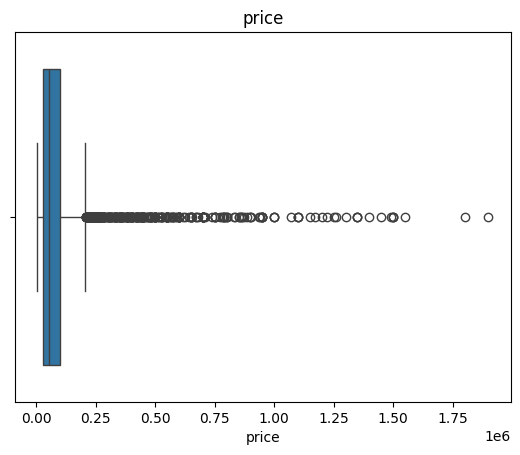

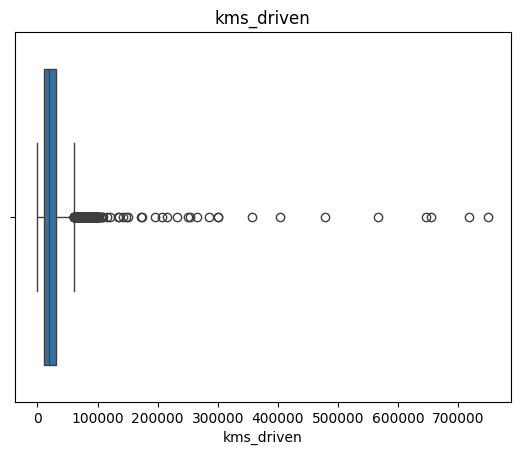

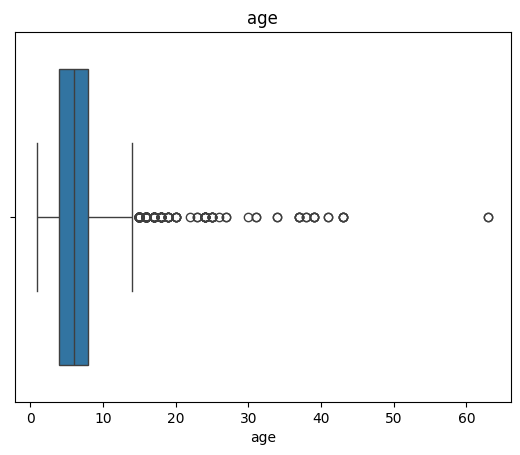

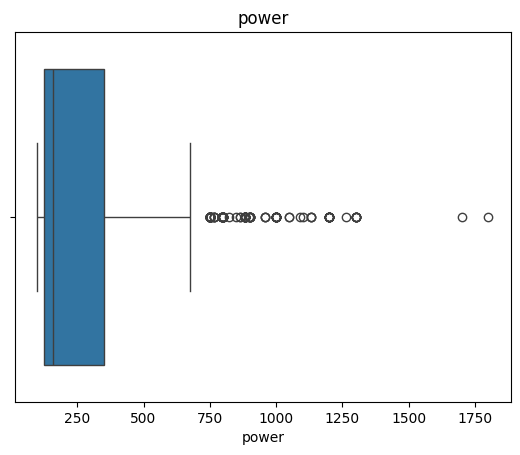

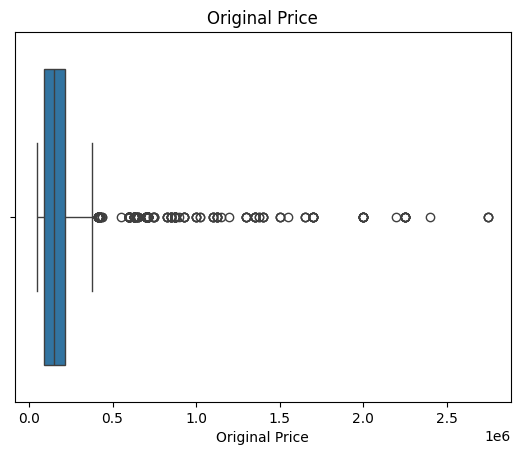

In [16]:
# to check outlair
for col in df.select_dtypes(include=[np.number]).columns:
    sns.boxplot(x = df[col])
    plt.title(col)
    plt.show()

In [17]:
# for taking numeric data 
df_num = df.select_dtypes(include=[np.number])
df_num

,price,kms_driven,age,power,Original Price
0,35000,17654,3,110,82500
1,119900,11000,4,350,230000
2,600000,110,8,675,1100000
3,65000,16329,4,180,140000
4,80000,10000,3,150,150000
...,...,...,...,...,...
7307,25000,48587,8,150,120000
7308,35000,60000,9,220,160000
7309,450000,3430,4,750,630000
7310,139000,21300,4,400,245000


In [18]:
# for replacing outlairs we will use knn imputers
from sklearn.impute import KNNImputer
# replacing outlair into null value 
q1 = df_num.quantile(0.25)
q3 = df_num.quantile(0.75)
iqr = q3-q1
lower = q1-1.5*iqr
upper = q3+1.5 * iqr



In [19]:
# taking outlair data  and filling with nul value
df_num[(df_num<= lower) |  (df_num>=upper)]=np.nan

In [20]:
df_num.isnull().sum()

price             349
kms_driven        334
age               332
power             168
Original Price    256
dtype: int64

In [21]:
# initialising knn imputer for fillting null values
imputer = KNNImputer(n_neighbors=3)
df_clean = pd.DataFrame(imputer.fit_transform(df_num),columns=df_num.columns)

In [22]:
df_clean.isnull().sum()

price             0
kms_driven        0
age               0
power             0
Original Price    0
dtype: int64

In [23]:
df_clean

,price,kms_driven,age,power,Original Price
0,35000.0,17654.0,3.0,110.000000,82500.000000
1,119900.0,11000.0,4.0,350.000000,230000.000000
2,134000.0,110.0,8.0,675.000000,296666.666667
3,65000.0,16329.0,4.0,180.000000,140000.000000
4,80000.0,10000.0,3.0,150.000000,150000.000000
...,...,...,...,...,...
7306,25000.0,48587.0,8.0,150.000000,120000.000000
7307,35000.0,60000.0,9.0,220.000000,160000.000000
7308,38455.0,3430.0,4.0,186.666667,160000.000000
7309,139000.0,21300.0,4.0,400.000000,245000.000000


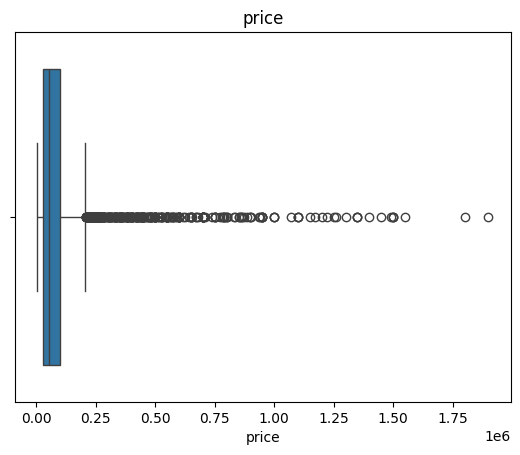

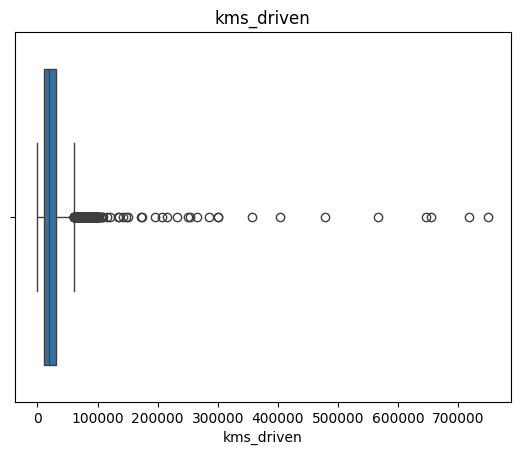

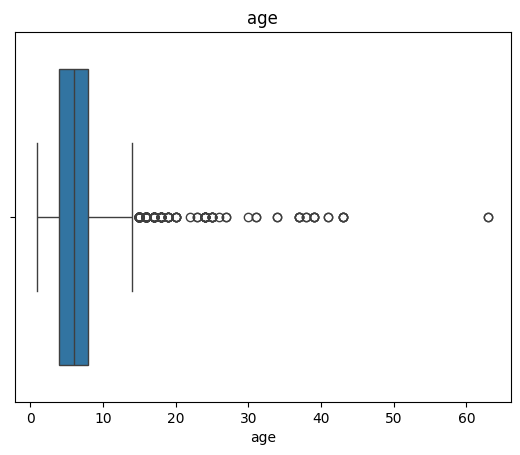

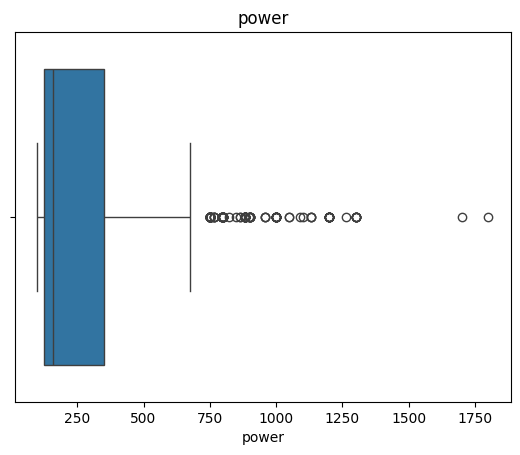

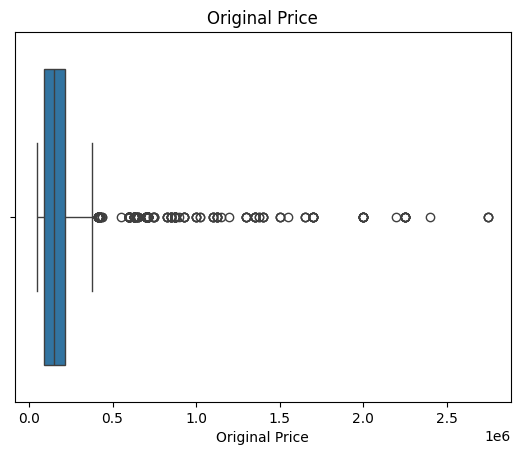

In [24]:
# rechaking outlair 
for col in df_clean.select_dtypes(include=[np.number]).columns:
    sns.boxplot(x = df[col])
    plt.title(col)
    plt.show()

In [25]:
df_clean.columns


Index(['price', 'kms_driven', 'age', 'power', 'Original Price'], dtype='object')

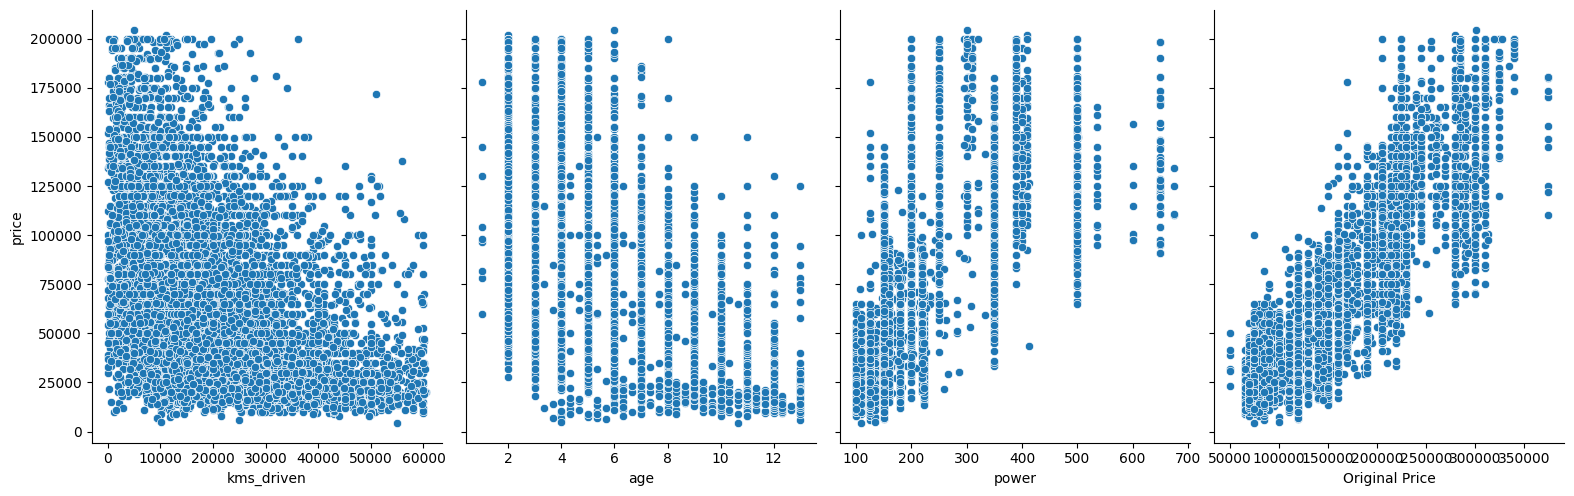

In [26]:
sns.pairplot(df_clean,x_vars=['kms_driven', 'age', 'power', 'Original Price'], y_vars='price', height=5, aspect=0.8)
plt.show()

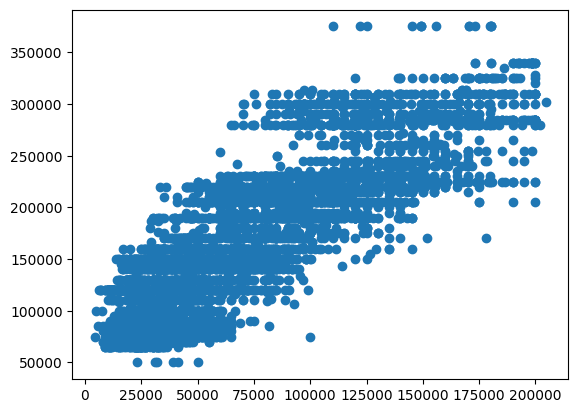

In [27]:
plt.scatter(df_clean['price'],df_clean['Original Price'])

In [28]:
df_clean['price'].corr(df_clean['Original Price'])

np.float64(0.8651981943931886)

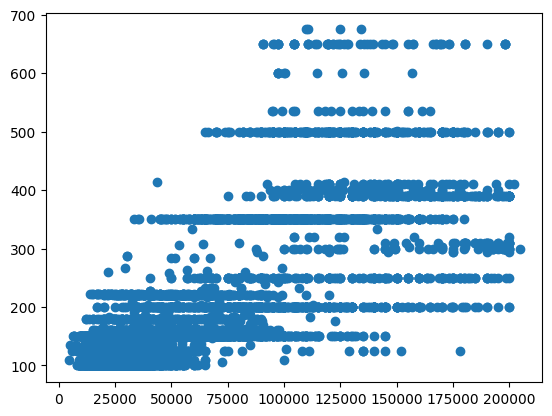

In [29]:
plt.scatter(df_clean['price'],df_clean['power'])

In [30]:
df_clean['price'].corr(df_clean['power'])

np.float64(0.7446608630951637)

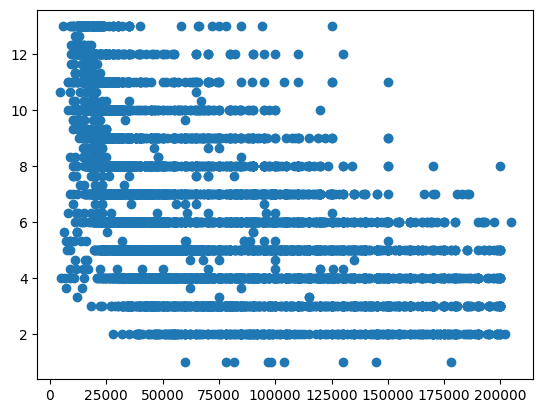

In [31]:
plt.scatter(df_clean['price'],df_clean['age'])

In [32]:
df_clean['price'].corr(df_clean['age'])

np.float64(-0.5456312780380878)

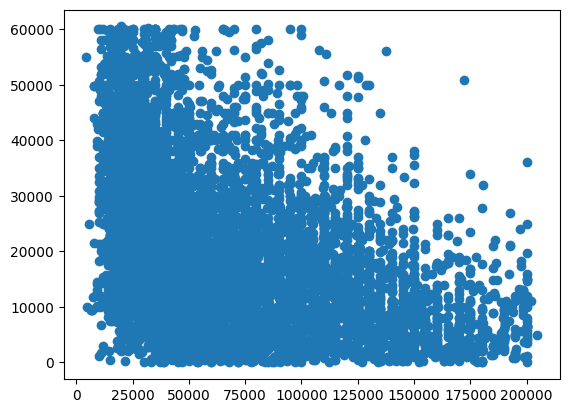

In [33]:
plt.scatter(df_clean['price'],df_clean['kms_driven'])

In [34]:
df_clean['price'].corr(df_clean['kms_driven'])

np.float64(-0.42832880480143154)

In [35]:
# for concodination we need to drop the columns form original dataframe 
df.columns

Index(['price', 'city', 'kms_driven', 'owner', 'age', 'power', 'brand',
       'Original Price'],
      dtype='object')

In [36]:
df.drop(['price', 'kms_driven', 'age', 'power','Original Price'],inplace=True,axis=1)

In [37]:
df

,city,owner,brand
0,ahmedabad,First Owner,tvs
1,delhi,First Owner,royal enfield
2,delhi,First Owner,triumph
3,bangalore,First Owner,tvs
4,bangalore,First Owner,yamaha
...,...,...,...
7307,delhi,First Owner,hero
7308,bangalore,First Owner,bajaj
7309,jodhpur,First Owner,harley-davidson
7310,hyderabad,First Owner,bajaj


In [38]:
df_clean

,price,kms_driven,age,power,Original Price
0,35000.0,17654.0,3.0,110.000000,82500.000000
1,119900.0,11000.0,4.0,350.000000,230000.000000
2,134000.0,110.0,8.0,675.000000,296666.666667
3,65000.0,16329.0,4.0,180.000000,140000.000000
4,80000.0,10000.0,3.0,150.000000,150000.000000
...,...,...,...,...,...
7306,25000.0,48587.0,8.0,150.000000,120000.000000
7307,35000.0,60000.0,9.0,220.000000,160000.000000
7308,38455.0,3430.0,4.0,186.666667,160000.000000
7309,139000.0,21300.0,4.0,400.000000,245000.000000


In [39]:
df.reset_index(drop=True,inplace=True)

In [40]:
df_clean.reset_index(drop=True,inplace=True)

In [41]:
ori_df = pd.concat([df,df_clean],axis=1)

In [42]:
df.isnull().sum()

city     0
owner    0
brand    0
dtype: int64

In [43]:
ori_df.isnull().sum()

city              0
owner             0
brand             0
price             0
kms_driven        0
age               0
power             0
Original Price    0
dtype: int64

In [44]:
ori_df.isnull().sum()

city              0
owner             0
brand             0
price             0
kms_driven        0
age               0
power             0
Original Price    0
dtype: int64

In [45]:
multi_df =ori_df.select_dtypes(include=[np.number]).drop('price',axis=1)

In [46]:
multi_df

,kms_driven,age,power,Original Price
0,17654.0,3.0,110.000000,82500.000000
1,11000.0,4.0,350.000000,230000.000000
2,110.0,8.0,675.000000,296666.666667
3,16329.0,4.0,180.000000,140000.000000
4,10000.0,3.0,150.000000,150000.000000
...,...,...,...,...
7306,48587.0,8.0,150.000000,120000.000000
7307,60000.0,9.0,220.000000,160000.000000
7308,3430.0,4.0,186.666667,160000.000000
7309,21300.0,4.0,400.000000,245000.000000


In [47]:
multi_df=ori_df.select_dtypes(include=[np.number]).drop(['price','Original Price'],axis=1)

In [48]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_df =pd.DataFrame()
vif_df['features']=multi_df.columns
vif_df['vif']=[variance_inflation_factor(multi_df.values,i) for i in range(multi_df.shape[1])]

In [49]:
vif_df

,features,vif
0,kms_driven,4.422939
1,age,5.749588
2,power,2.389771


In [50]:
ori_df.drop('Original Price',axis=1,inplace=True)

<Axes: xlabel='brand'>

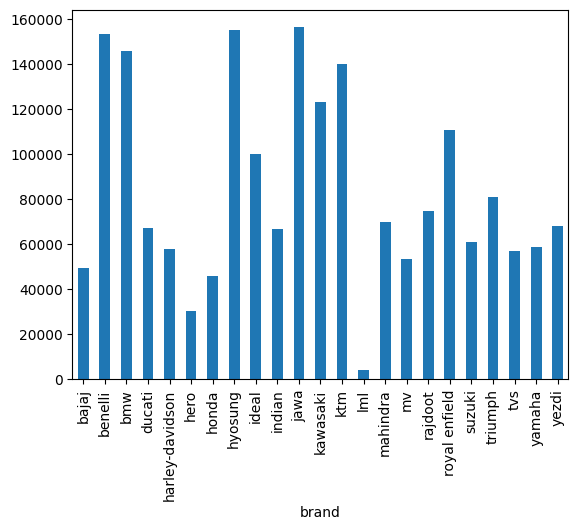

In [51]:
ori_df.groupby('brand')['price'].mean().plot(kind='bar')

In [52]:
ori_df['brand'].value_counts()

brand
bajaj              2031
royal enfield      1364
hero               1167
honda               672
yamaha              651
tvs                 481
ktm                 375
suzuki              203
harley-davidson      91
kawasaki             61
hyosung              52
mahindra             50
benelli              46
triumph              21
ducati               19
bmw                  10
jawa                  7
indian                3
mv                    3
rajdoot               1
lml                   1
yezdi                 1
ideal                 1
Name: count, dtype: int64

In [53]:
ori_df= ori_df[ori_df['brand'].map((ori_df['brand'].value_counts())>100)]

In [54]:
ori_df['owner'].value_counts()

owner
First Owner             6311
Second Owner             546
Third Owner               76
Fourth Owner Or More      11
Name: count, dtype: int64

In [55]:
df

,city,owner,brand
0,ahmedabad,First Owner,tvs
1,delhi,First Owner,royal enfield
2,delhi,First Owner,triumph
3,bangalore,First Owner,tvs
4,bangalore,First Owner,yamaha
...,...,...,...
7306,delhi,First Owner,hero
7307,bangalore,First Owner,bajaj
7308,jodhpur,First Owner,harley-davidson
7309,hyderabad,First Owner,bajaj


In [56]:
ori_df

,city,owner,brand,price,kms_driven,age,power
0,ahmedabad,First Owner,tvs,35000.0,17654.0,3.0,110.0
1,delhi,First Owner,royal enfield,119900.0,11000.0,4.0,350.0
3,bangalore,First Owner,tvs,65000.0,16329.0,4.0,180.0
4,bangalore,First Owner,yamaha,80000.0,10000.0,3.0,150.0
5,delhi,First Owner,yamaha,53499.0,25000.0,6.0,150.0
...,...,...,...,...,...,...,...
7305,bangalore,First Owner,bajaj,50000.0,29134.0,7.0,220.0
7306,delhi,First Owner,hero,25000.0,48587.0,8.0,150.0
7307,bangalore,First Owner,bajaj,35000.0,60000.0,9.0,220.0
7309,hyderabad,First Owner,bajaj,139000.0,21300.0,4.0,400.0


In [57]:
le_owner = LabelEncoder()
ori_df['owner_encoded']=le_owner.fit_transform(ori_df['owner'])

le_brand = LabelEncoder()
ori_df['brand_encoded']=le_brand.fit_transform(ori_df['brand'])

le_city = LabelEncoder()
ori_df['city_encoded']=le_city.fit_transform(ori_df['city'])

In [58]:
ori_df

,city,owner,brand,price,kms_driven,age,power,owner_encoded,brand_encoded,city_encoded
0,ahmedabad,First Owner,tvs,35000.0,17654.0,3.0,110.0,0,6,6
1,delhi,First Owner,royal enfield,119900.0,11000.0,4.0,350.0,0,4,111
3,bangalore,First Owner,tvs,65000.0,16329.0,4.0,180.0,0,6,43
4,bangalore,First Owner,yamaha,80000.0,10000.0,3.0,150.0,0,7,43
5,delhi,First Owner,yamaha,53499.0,25000.0,6.0,150.0,0,7,111
...,...,...,...,...,...,...,...,...,...,...
7305,bangalore,First Owner,bajaj,50000.0,29134.0,7.0,220.0,0,0,43
7306,delhi,First Owner,hero,25000.0,48587.0,8.0,150.0,0,1,111
7307,bangalore,First Owner,bajaj,35000.0,60000.0,9.0,220.0,0,0,43
7309,hyderabad,First Owner,bajaj,139000.0,21300.0,4.0,400.0,0,0,175


In [59]:
ori_df.columns

Index(['city', 'owner', 'brand', 'price', 'kms_driven', 'age', 'power',
       'owner_encoded', 'brand_encoded', 'city_encoded'],
      dtype='object')

In [60]:
x= ori_df[[ 'kms_driven', 'age', 'power',
       'owner_encoded', 'brand_encoded', 'city_encoded']]

y = ori_df['price']

In [70]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=22)

In [71]:
scaler = StandardScaler()
x_train_scaler = scaler.fit_transform(x_train)
x_test_scaler = scaler.fit_transform(x_test)

In [72]:
import statsmodels.api as sm 

In [73]:
x_train = sm.add_constant(x_train_scaler)

In [74]:
x_test=sm.add_constant(x_test_scaler)

In [75]:
x_train

array([[ 1.        , -0.17805187, -0.12894041, ...,  4.55116916,
         0.20097621,  1.49587563],
       [ 1.        ,  2.11827714,  0.60456087, ..., -0.31008158,
        -1.06672573, -0.56848096],
       [ 1.        ,  0.85455352, -0.12894041, ..., -0.31008158,
         0.20097621,  1.01251409],
       ...,
       [ 1.        , -0.07259303, -0.49569106, ..., -0.31008158,
        -0.2215911 , -0.89072199],
       [ 1.        , -0.05699701,  0.60456087, ..., -0.31008158,
         1.46867815, -1.25324315],
       [ 1.        , -0.20649605, -0.49569106, ..., -0.31008158,
        -0.64415842, -0.35701029]], shape=(5555, 7))

In [76]:
x_test

array([[ 1.        , -0.22702712, -0.52116555, ..., -0.31895361,
        -0.64627589, -0.51181339],
       [ 1.        , -0.96406653, -0.88311503, ..., -0.31895361,
         1.03319503,  0.14880577],
       [ 1.        , -0.41644625,  0.2027334 , ..., -0.31895361,
        -0.64627589, -0.14021511],
       ...,
       [ 1.        , -0.81665865, -0.15921608, ..., -0.31895361,
        -0.64627589,  0.21073882],
       [ 1.        ,  2.13149901, -0.88311503, ..., -0.31895361,
         1.87293049, -1.54403083],
       [ 1.        , -0.374435  , -0.15921608, ..., -0.31895361,
        -1.06614362, -0.02667119]], shape=(1389, 7))

In [77]:
model = sm.OLS(y_train,x_train).fit()

In [78]:
y_train.shape

(5555,)

In [79]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.775
Model:                            OLS   Adj. R-squared:                  0.775
Method:                 Least Squares   F-statistic:                     3189.
Date:                Thu, 01 Jan 2026   Prob (F-statistic):               0.00
Time:                        18:50:27   Log-Likelihood:                -63034.
No. Observations:                5555   AIC:                         1.261e+05
Df Residuals:                    5548   BIC:                         1.261e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6.493e+04    275.275    235.863      0.0

In [82]:
lr = LinearRegression()


In [83]:
lr.fit(x_train_scaler,y_train)

LinearRegression()

In [85]:
y_pred = lr.predict(x_test_scaler)

In [87]:
r2_score(y_test,y_pred)

0.7604721124257863

In [90]:
import joblib
joblib.dump(lr, 'used_bike_price_model.pkl')
joblib.dump(scaler,'scaler.pkl')
joblib.dump(le_brand,'brand_encoder.pkl')
joblib.dump(le_owner,'owner_encoder.pkl')
joblib.dump(le_city,'city_encoder.pkl')
print('MOdel and encoders saved successfully!')

MOdel and encoders saved successfully!
